In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T = np.arange(0.02, 0.84, 0.02, dtype=np.float32)
alpha=0.2
distance = -np.log10(T)*(10/alpha) # tau = 10^(-alpha*d/10)
excess_noise = 0.005
VA = 1
V = VA + 1

beta = np.loadtxt("Beta_skr_calculation.txt", dtype=np.float32)

SNR_list = (T * (VA) / (1 + excess_noise))#.astype(np.float32) #homodyne case
SNRdB_list = (10 * np.log10(SNR_list))#.astype(np.float32)

I_AB = 0.5 * np.log2((1 + SNR_list))

ber = np.loadtxt("Ber.txt", dtype=np.float32)
capacity = np.loadtxt("Capacidade.txt", dtype=np.float32)



In [107]:
#Channel parameters

df = pd.DataFrame(SNRdB_list, columns=['SNR (dB)'])
df["SNR"] = SNR_list
df["Range"] = distance
df["Transmittance"] = T
df["Efficiency (4)"] = beta[:,0]
#df["Efficiency (2)"] = beta[:,2]
df["I(A;B)"] = I_AB
df["Capacity Ch1"] = capacity[:,0]
#df["Capacity Ch2"] = capacity[:,1]
df["BER Ch1"] = ber[:,0]
df["Log(BER) Ch1"] = np.log10(df['BER Ch1'])
#df["BER Ch2"] = ber[:,1]

display(df)

,SNR (dB),SNR,Range,Transmittance,Efficiency (4),I(A;B),Capacity Ch1,BER Ch1,Log(BER) Ch1
0,-17.011360,0.019900,84.948502,0.02,0.986147,0.014214,0.022741,0.412852,-0.384206
1,-14.001060,0.039801,69.897003,0.04,0.938966,0.028154,0.042812,0.379820,-0.420422
2,-12.240149,0.059701,61.092438,0.06,0.911325,0.041829,0.060997,0.356510,-0.447928
3,-10.990761,0.079602,54.845501,0.08,0.899720,0.055250,0.077285,0.338518,-0.470418
4,-10.021660,0.099502,50.000000,0.10,0.886219,0.068425,0.094947,0.321254,-0.493151
5,-9.229849,0.119403,46.040939,0.12,0.876054,0.081365,0.109436,0.308384,-0.510908
6,-8.560380,0.139303,42.693596,0.14,0.864349,0.094076,0.122854,0.297263,-0.526859
7,-7.980461,0.159204,39.794003,0.16,0.856389,0.106567,0.135754,0.287123,-0.541932
8,-7.468936,0.179104,37.236374,0.18,0.847636,0.118846,0.149553,0.276928,-0.557633
9,-7.011361,0.199005,34.948502,0.20,0.840909,0.130919,0.158651,0.270398,-0.567997


In [108]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X = df[["SNR (dB)", "Transmittance"]]
y = df["Log(BER) Ch1"]

X_train_RF, X_test_RF, y_train_RF, y_test_RF = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train_RF, y_train_RF)

pred = model.predict(X_test_RF)

print("Mean square error: ", mean_squared_error(y_test_RF, pred))
print(model.feature_importances_)

Mean square error:  1.7505333844715262e-05
[0.55576943 0.44423057]


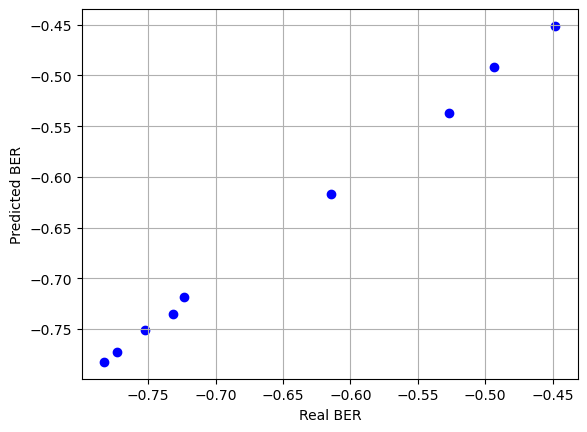

In [109]:
plt.scatter(y_test_RF, pred, color="blue")
plt.xlabel("Real BER")
plt.ylabel("Predicted BER")
plt.grid(True)
plt.show()

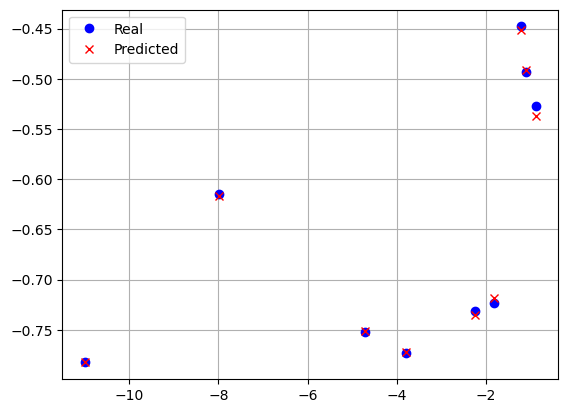

In [110]:
plt.plot(X_test["SNR (dB)"], y_test_RF, "o", label="Real", color="blue")
plt.plot(X_test["SNR (dB)"], pred, "x", label="Predicted", color="red")
plt.grid(True)
plt.legend()
plt.show()

In [111]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

#same as previously
X = df[["SNR (dB)", "Transmittance"]]
y = df["Log(BER) Ch1"]

X_train_LR, X_test_LR, y_train_LR, y_test_LR = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train_LR, y_train_LR)
pred_LR = model.predict(X_test_LR)

mse = mean_squared_error(y_test_LR, pred_LR)

print("Mean squared error: ", mse)

r2 = r2_score(y_test_LR, pred_LR)
print("R^2: ", r2)

print("Model coefficients: ", model.coef_)
print(model.intercept_)

Mean squared error:  3.400702917133458e-05
R^2:  0.9962998628616333
Model coefficients:  [-0.01687751 -0.20118098]
-0.650577


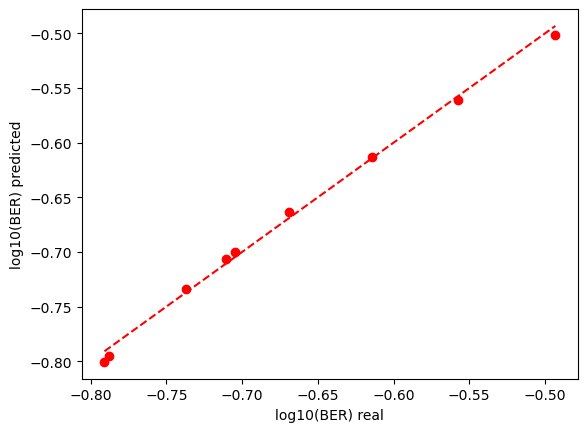

In [113]:
plt.scatter(y_test_LR, pred_LR, color = "red")
#plt.scatter(y_test_RF, pred, color = 'blue')

plt.xlabel("log10(BER) real")
plt.ylabel("log10(BER) predicted")

plt.plot(
    [y_test_LR.min(), y_test_LR.max()],
    [y_test_LR.min(), y_test_LR.max()],
    '--', color = "red"
)
"""plt.plot(
    [y_test_RF.min(), y_test_RF.max()],
    [y_test_RF.min(), y_test_RF.max()],
    '--'
)"""

plt.show()

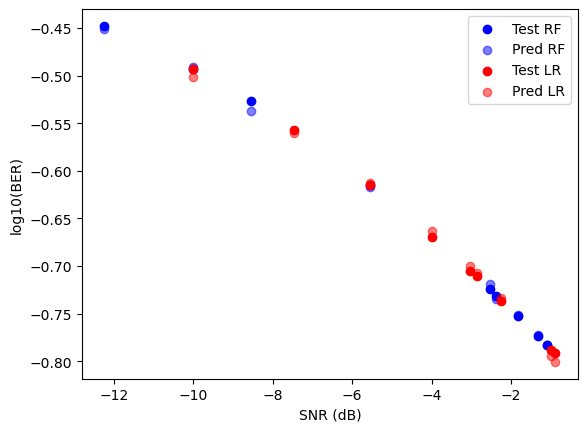

In [114]:
plt.scatter(
    X_test_RF["SNR (dB)"],
    y_test_RF,
    label="Test RF",
    color = "blue"
)

plt.scatter(
    X_test_RF["SNR (dB)"],
    pred,
    label="Pred RF",
    color = "blue",
    alpha=0.5
)

plt.scatter(
    X_test_LR["SNR (dB)"],
    y_test_LR,
    label="Test LR",
    color = "red"
)

plt.scatter(
    X_test_LR["SNR (dB)"],
    pred_LR,
    label="Pred LR",
    color = "red",
    alpha=0.5
)

#plt.plot(df["SNR (dB)"], df["Log(BER) Ch1"], color="blue")
plt.xlabel("SNR (dB)")
plt.ylabel("log10(BER)")
plt.legend()

plt.show()